<a href="https://colab.research.google.com/github/k-2229/eng-ai-agents-public/blob/main/notebooks/assignments/topics/cnn-explainers/index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install captum

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from captum.attr import IntegratedGradients, LayerGradCam
from captum.attr import visualization as viz

In [3]:
IMG_SIZE = 150
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallConvNet(nn.Module):
    def __init__(self, dropout=True):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)

In [4]:
ds_dict = load_dataset("pantelism/cats-vs-dogs")

basic_tf = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img = sample["image"].convert("RGB")
        label = sample["label"]
        return self.transform(img), label

test_dataset = CatsDogsDataset(ds_dict["test"], basic_tf)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [5]:
model = SmallConvNet(dropout=True).to(DEVICE)
model.load_state_dict(
    torch.load("/content/cats_and_dogs_small.pth", map_location=DEVICE)
)

model.eval()

SmallConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=6272, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [6]:
correct_examples = []
wrong_examples = []

model.eval()

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(DEVICE)

        output = model(img)
        prob = torch.sigmoid(output).item()

        prediction = 1 if prob > 0.5 else 0

        if prediction == label.item() and len(correct_examples) < 3:
            correct_examples.append((img.cpu(), label.item(), prediction))

        elif prediction != label.item() and len(wrong_examples) < 1:
            wrong_examples.append((img.cpu(), label.item(), prediction))

        if len(correct_examples) == 3 and len(wrong_examples) == 1:
            break

print("Correct examples found:", len(correct_examples))
print("Wrong examples found:", len(wrong_examples))

Correct examples found: 3
Wrong examples found: 1


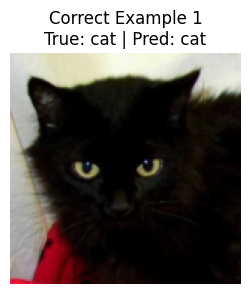

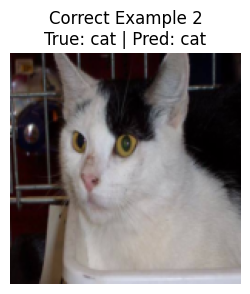

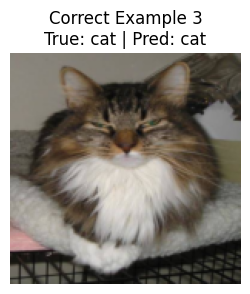

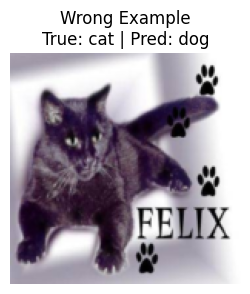

In [7]:
import matplotlib.pyplot as plt

def show_example(example, title):
    img, label, pred = example

    # Convert from normalized tensor back to image
    img = img.squeeze(0).permute(1, 2, 0)
    img = (img * 0.5) + 0.5   # undo normalization

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{title}\nTrue: {'dog' if label==1 else 'cat'} | "
        f"Pred: {'dog' if pred==1 else 'cat'}"
    )
    plt.show()


for i, ex in enumerate(correct_examples):
    show_example(ex, f"Correct Example {i+1}")

show_example(wrong_examples[0], "Wrong Example")

## Integrated Gradients Explanation

Integrated Gradients explains which pixels contributed to the CNN prediction. It compares the input image with a baseline image (usually a black image) and accumulates gradients along the path between the baseline and the original image. Pixels with larger attribution values have a stronger effect on the model's decision.

The baseline is important because it represents an uninformative input, allowing the method to measure how much each pixel changes the model output.

One limitation of Integrated Gradients is that the pixel-level explanations can sometimes be noisy and difficult to interpret.

In [8]:
from captum.attr import IntegratedGradients

# Create Integrated Gradients object
ig = IntegratedGradients(model)

# Choose the wrong example first
img, label, pred = wrong_examples[0]

img = img.to(DEVICE)

# Compute attribution
attributions = ig.attribute(
    img,
    target=None
)

print(attributions.shape)

torch.Size([1, 3, 150, 150])


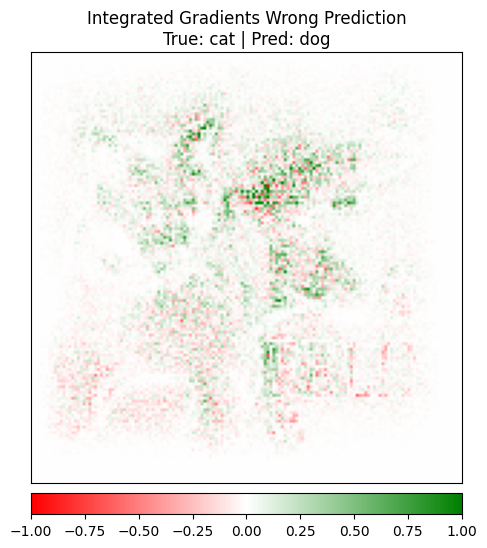

In [9]:
from captum.attr import visualization as viz

attr = attributions.squeeze().cpu().detach().numpy()
attr = np.transpose(attr, (1,2,0))

original = img.squeeze().cpu().detach().numpy()
original = np.transpose(original, (1,2,0))

# Undo normalization
original = (original * 0.5) + 0.5
original = np.clip(original, 0, 1)

viz.visualize_image_attr(
    attr,
    original,
    method="heat_map",
    sign="all",
    show_colorbar=True,
    title=f"Integrated Gradients Wrong Prediction\nTrue: {'dog' if label==1 else 'cat'} | Pred: {'dog' if pred==1 else 'cat'}"
)

plt.show()

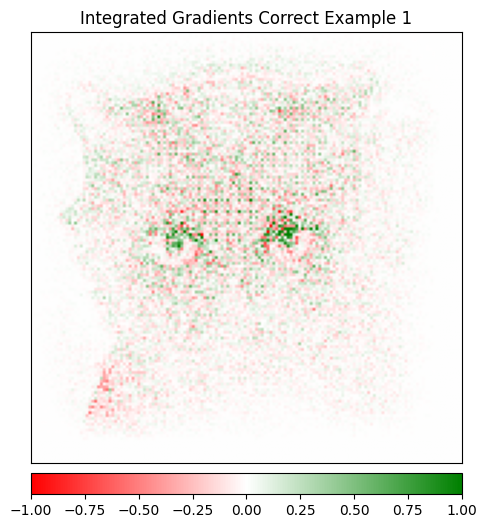

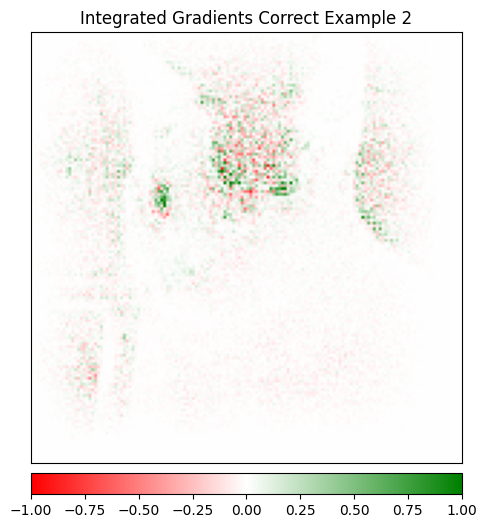

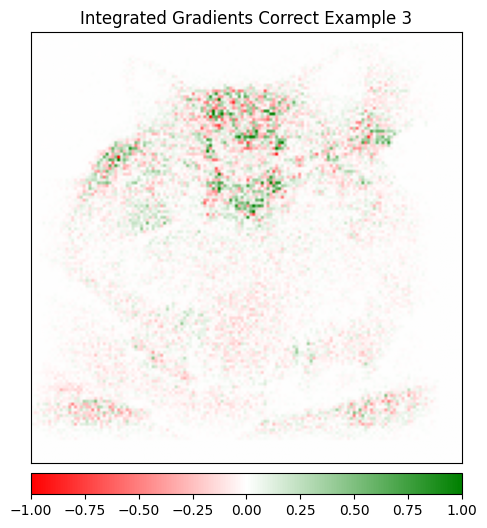

In [10]:
for i, example in enumerate(correct_examples):

    correct_img, correct_label, correct_pred = example
    correct_img = correct_img.to(DEVICE)

    correct_attr = ig.attribute(
        correct_img,
        target=None
    )

    attr = correct_attr.squeeze(0).detach().cpu().numpy()

    img_np = correct_img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
    img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np,0,1)

    attr = np.transpose(attr,(1,2,0))

    viz.visualize_image_attr(
        attr,
        img_np,
        method="heat_map",
        sign="all",
        show_colorbar=True,
        title=f"Integrated Gradients Correct Example {i+1}"
    )

    plt.show()

## Grad-CAM Explanation

Grad-CAM highlights the image regions that influence the CNN prediction. It uses the gradients of the predicted class flowing into the feature maps of a convolutional layer. The final convolutional layer is used because it contains high-level visual features while keeping spatial information.

The target layer is the last convolutional layer of the CNN because it provides meaningful object-level features.

One limitation of Grad-CAM is that the heatmap has lower resolution than the original image, so it gives a coarse localization rather than exact pixel importance.

In [11]:
from captum.attr import LayerGradCam, LayerAttribution
gradcam = LayerGradCam(
    model,
    model.features[10]   # last ReLU layer before final pooling
)

In [12]:
img, label, pred = wrong_examples[0]

img = img.to(DEVICE)

cam_attr = gradcam.attribute(
    img,
    target=None
)

print(cam_attr.shape)

torch.Size([1, 1, 15, 15])


In [13]:
upsampled_cam = LayerAttribution.interpolate(
    cam_attr,
    (150,150)
)

print(upsampled_cam.shape)

torch.Size([1, 1, 150, 150])


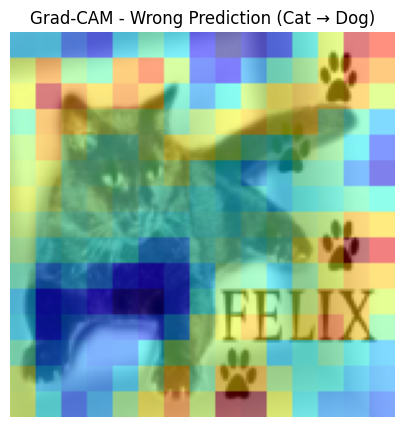

In [14]:
cam = upsampled_cam.squeeze().detach().cpu().numpy()

img_np = img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("Grad-CAM - Wrong Prediction (Cat → Dog)")
plt.show()

The CNN incorrectly classified this cat image as a dog. The Grad-CAM heatmap shows that the model focused on visual features that were confusing, possibly including the background, fur patterns, or shape features that overlap between cats and dogs.

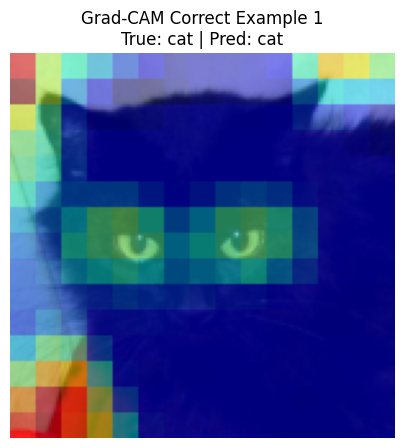

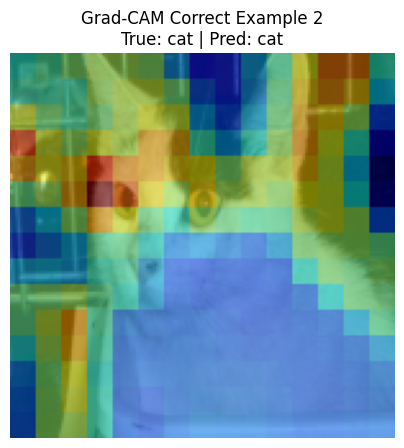

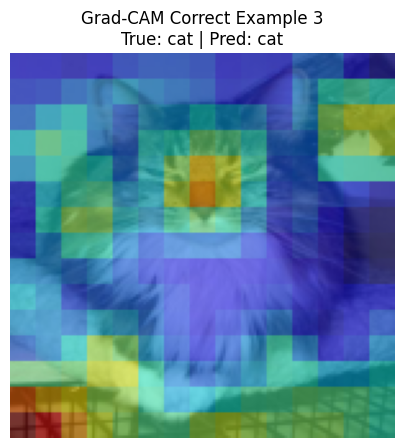

In [15]:
for i, example in enumerate(correct_examples):

    img, label, pred = example
    img = img.to(DEVICE)

    cam_attr = gradcam.attribute(
        img,
        target=None
    )

    upsampled_cam = LayerAttribution.interpolate(
        cam_attr,
        (150,150)
    )

    cam = upsampled_cam.squeeze().detach().cpu().numpy()

    img_np = img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
    img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np,0,1)

    plt.figure(figsize=(5,5))
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.title(
        f"Grad-CAM Correct Example {i+1}\n"
        f"True: {'dog' if label==1 else 'cat'} | "
        f"Pred: {'dog' if pred==1 else 'cat'}"
    )
    plt.show()

The Grad-CAM results for correctly classified images show that the model generally focused on important regions of the animals, such as the face, ears, and body shape. Compared with the incorrect prediction, the model appeared to use more relevant animal features when making correct decisions.

In [16]:
wrong_img, wrong_label, wrong_pred = wrong_examples[0]

wrong_img = wrong_img.to(DEVICE)

print("True label:", wrong_label)
print("Predicted:", wrong_pred)

True label: 0
Predicted: 1


In [17]:
wrong_cam_attr = gradcam.attribute(
    wrong_img
)

print(wrong_cam_attr.shape)

torch.Size([1, 1, 15, 15])


In [18]:
wrong_upsampled_cam = LayerAttribution.interpolate(
    wrong_cam_attr,
    (IMG_SIZE, IMG_SIZE)
)

wrong_cam = wrong_upsampled_cam.squeeze().detach().numpy()

print(wrong_cam.shape)

(150, 150)


In [19]:
wrong_img_np = wrong_img.squeeze().permute(1,2,0).detach().numpy()

wrong_img_np = (wrong_img_np * 0.5) + 0.5
wrong_img_np = np.clip(wrong_img_np, 0, 1)

print(wrong_img_np.shape)

(150, 150, 3)


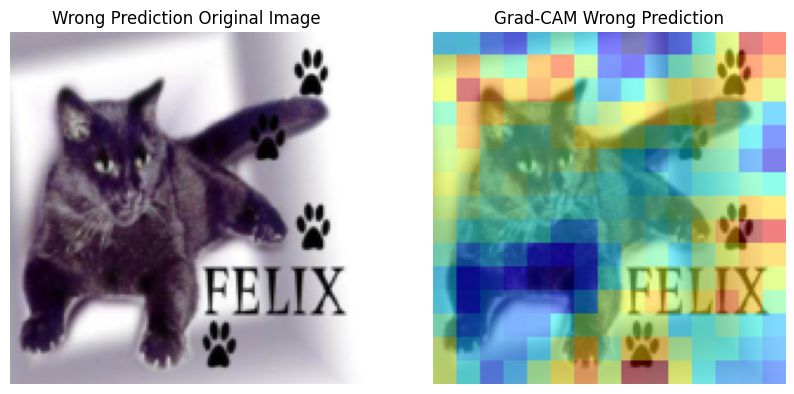

In [20]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(wrong_img_np)
plt.title("Wrong Prediction Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wrong_img_np)
plt.imshow(wrong_cam, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Wrong Prediction")
plt.axis("off")

plt.savefig(
    "gradcam_wrong_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

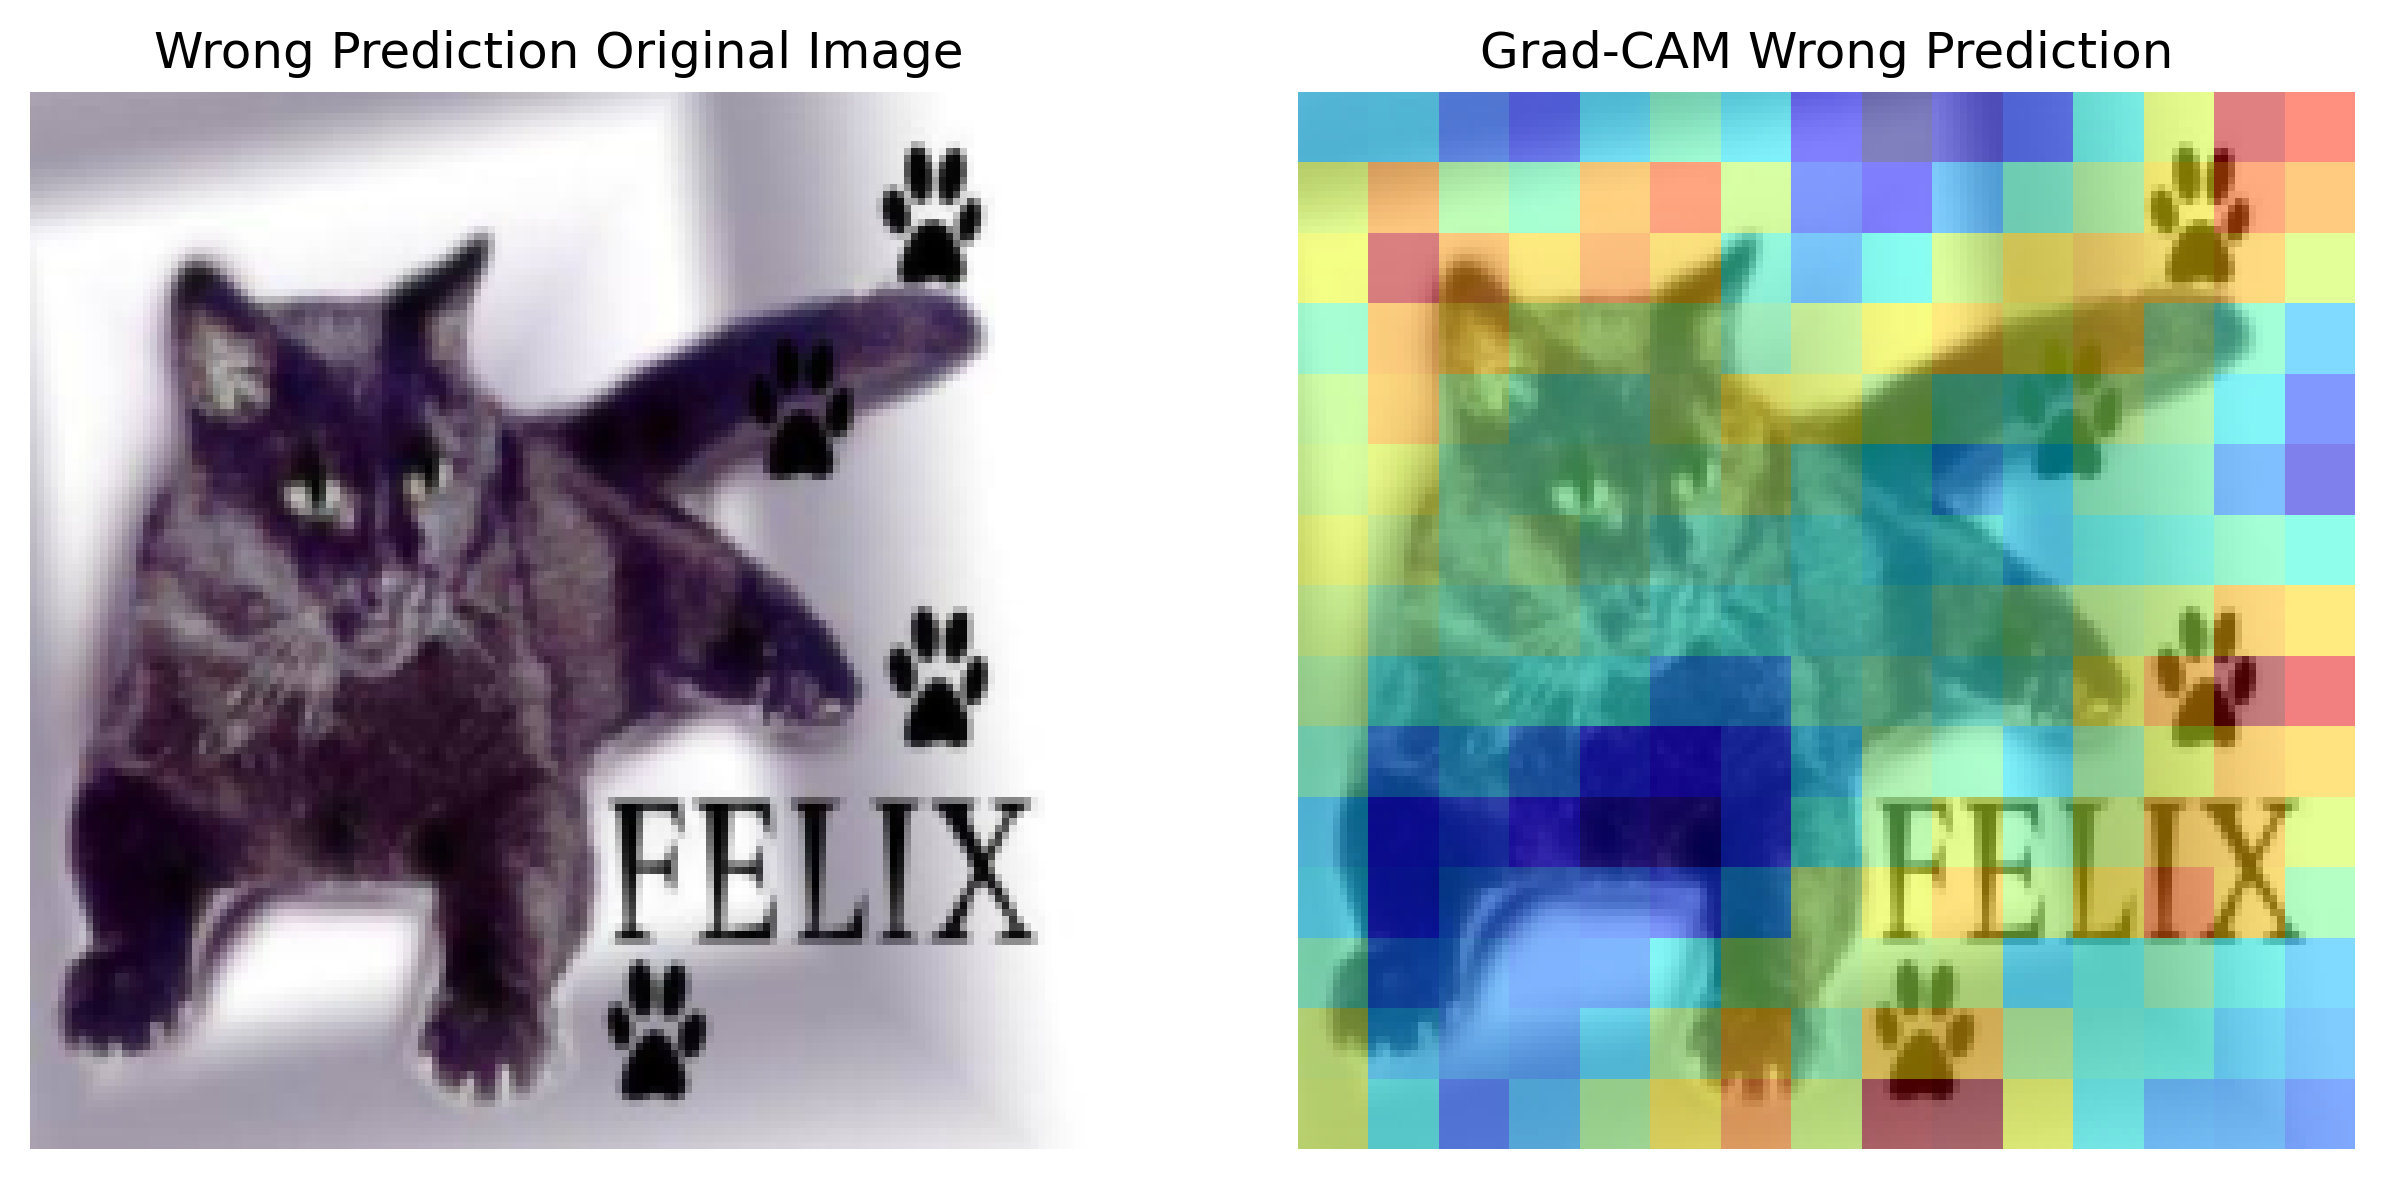

In [21]:
from IPython.display import Image

Image("gradcam_wrong_prediction.png")

## Interpretation of Results

Integrated Gradients and Grad-CAM both show which parts of the image affected the model prediction. When the methods agree, the highlighted regions usually correspond to important animal features such as the face, body, or fur.

The methods can disagree because Integrated Gradients provides pixel-level details, while Grad-CAM highlights larger regions from the CNN feature maps.

For the misclassified example, both explanations suggest that the model focused on features that were not specific enough to distinguish between cats and dogs. The model may have relied on overlapping features such as fur patterns, shape, or background information, which caused it to make an incorrect prediction.

Overall, Integrated Gradients gives a more detailed view of individual pixel contributions, while Grad-CAM provides a more general understanding of where the model focused. Using both methods together gives a better understanding of how the CNN makes decisions.